In [1]:
from google.colab import drive

drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import pandas as pd

weather_data_engineered = pd.read_csv('/content/drive/MyDrive/GlobalWeatherRepository_Engineered.csv')

In [2]:
import pandas as pd

weather_data_engineered = pd.read_csv('GlobalWeatherRepository_Engineered.csv')

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

weather_data_engineered['last_updated'] = pd.to_datetime(weather_data_engineered['last_updated'])

# Sort by time
weather_data_engineered = weather_data_engineered.sort_values('last_updated').reset_index(drop=True)

# Extract time features from last_updated
weather_data_engineered['hour']       = weather_data_engineered['last_updated'].dt.hour
weather_data_engineered['day']        = weather_data_engineered['last_updated'].dt.day
weather_data_engineered['month']      = weather_data_engineered['last_updated'].dt.month
weather_data_engineered['dayofweek']  = weather_data_engineered['last_updated'].dt.dayofweek
weather_data_engineered['dayofyear']  = weather_data_engineered['last_updated'].dt.dayofyear
weather_data_engineered['weekofyear'] = weather_data_engineered['last_updated'].dt.isocalendar().week.astype(int)

# Add cyclical encoding for hour and month (captures periodicity)
weather_data_engineered['hour_sin']  = np.sin(2 * np.pi * weather_data_engineered['hour'] / 24)
weather_data_engineered['hour_cos']  = np.cos(2 * np.pi * weather_data_engineered['hour'] / 24)
weather_data_engineered['month_sin'] = np.sin(2 * np.pi * weather_data_engineered['month'] / 12)
weather_data_engineered['month_cos'] = np.cos(2 * np.pi * weather_data_engineered['month'] / 12)

print("Time features added!")
print(weather_data_engineered[['last_updated', 'hour', 'day', 'month', 
                     'dayofyear', 'hour_sin', 'hour_cos',
                     'month_sin', 'month_cos']].head(3))

Time features added!
         last_updated  hour  day  month  dayofyear  hour_sin  hour_cos  \
0 2024-05-16 01:45:00     1   16      5        137  0.258819  0.965926   
1 2024-05-16 02:45:00     2   16      5        137  0.500000  0.866025   
2 2024-05-16 02:45:00     2   16      5        137  0.500000  0.866025   

   month_sin  month_cos  
0        0.5  -0.866025  
1        0.5  -0.866025  
2        0.5  -0.866025  


In [4]:
# Define feature columns
exclude_cols = [
    'last_updated', 'temperature_celsius', 'country', 'location_name',
    'timezone', 'last_updated_epoch', 'condition_text', 'condition_grouped',
    'wind_direction', 'moon_phase', 'season', 'time_of_day', 'uv_category',
    'sunrise', 'sunset', 'moonrise', 'moonset', 'sunrise_hour', 'sunset_hour'
]

feature_cols = [col for col in weather_data_engineered.columns 
                if col not in exclude_cols]

print("Features used for modeling:")
print(feature_cols)
print(f"\nTotal features: {len(feature_cols)}")

# Define X and y
X = weather_data_engineered[feature_cols]
y = weather_data_engineered['temperature_celsius']

# Time-based train/test split (80/20) — no shuffling to preserve time order
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTraining set: {X_train.shape[0]:,} rows")
print(f"Testing set:  {X_test.shape[0]:,} rows")

Features used for modeling:
['latitude', 'longitude', 'wind_mph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'visibility_km', 'moon_illumination', 'temp_range', 'heat_index', 'wind_chill', 'is_rainy', 'is_daytime', 'pollution_PC1', 'pollution_PC2', 'pollution_PC3', 'hour', 'day', 'month', 'dayofweek', 'dayofyear', 'weekofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

Total features: 28

Training set: 110,396 rows
Testing set:  27,599 rows


In [5]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler

# Replicate preprocessing scaling logic
robust_cols = [
    'wind_mph', 'pressure_mb',
    'visibility_km',
    'pollution_PC1', 'pollution_PC2', 'pollution_PC3'
]

minmax_cols = ['humidity', 'cloud', 'moon_illumination']

# Remaining numeric features get StandardScaler
standard_cols = [col for col in X_train.columns 
                 if col not in robust_cols + minmax_cols]

robust_scaler   = RobustScaler()
minmax_scaler   = MinMaxScaler()
standard_scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Fit on train only — transform both
for cols, sc in zip(
    [robust_cols, minmax_cols, standard_cols],
    [robust_scaler, minmax_scaler, standard_scaler]
):
    existing = [c for c in cols if c in X_train.columns]
    if existing:
        X_train_scaled[existing] = sc.fit_transform(X_train[existing])
        X_test_scaled[existing]  = sc.transform(X_test[existing])

print("Scaling applied consistently!")
print(f"RobustScaler applied to:   {[c for c in robust_cols if c in X_train.columns]}")
print(f"MinMaxScaler applied to:   {[c for c in minmax_cols if c in X_train.columns]}")
print(f"StandardScaler applied to: {[c for c in standard_cols if c in X_train.columns]}")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Scaling applied consistently!
RobustScaler applied to:   ['wind_mph', 'pressure_mb', 'visibility_km', 'pollution_PC1', 'pollution_PC2', 'pollution_PC3']
MinMaxScaler applied to:   ['humidity', 'cloud', 'moon_illumination']
StandardScaler applied to: ['latitude', 'longitude', 'wind_degree', 'precip_mm', 'temp_range', 'heat_index', 'wind_chill', 'is_rainy', 'is_daytime', 'hour', 'day', 'month', 'dayofweek', 'dayofyear', 'weekofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

X_train_scaled shape: (110396, 28)
X_test_scaled shape:  (27599, 28)


# Linear regression

=== Linear Regression Results ===
MAE:  0.4411°C
RMSE: 0.6979°C
R²:   0.9960


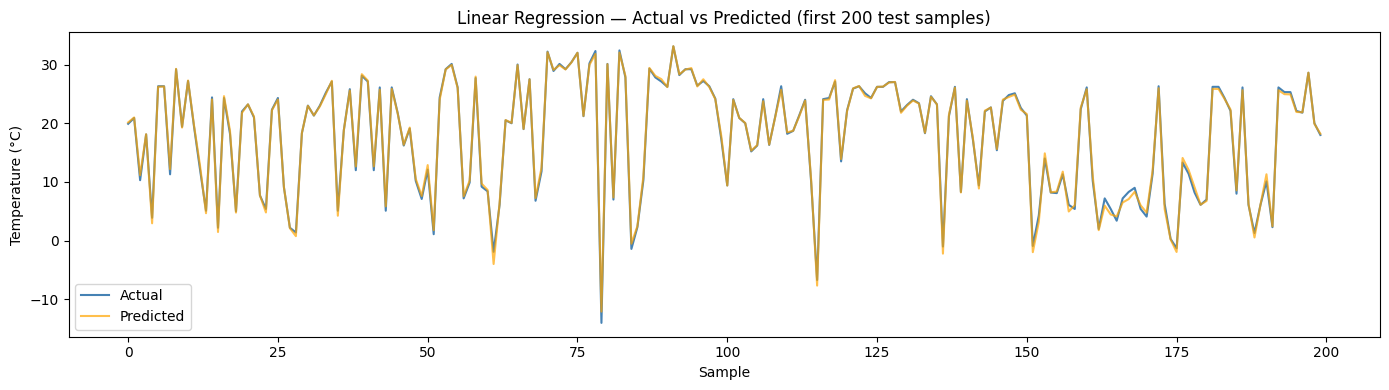

In [6]:
import matplotlib.pyplot as plt

# Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Metrics
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Results ===")
print(f"MAE:  {mae_lr:.4f}°C")
print(f"RMSE: {rmse_lr:.4f}°C")
print(f"R²:   {r2_lr:.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label='Actual', color='steelblue')
plt.plot(y_pred_lr[:200], label='Predicted', color='orange', alpha=0.7)
plt.title('Linear Regression — Actual vs Predicted (first 200 test samples)')
plt.xlabel('Sample')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

**Insights:**

- **R² of 0.9960** — the model explains 99.6% of temperature variance. Extremely high, which is impressive but also worth investigating for potential data leakage.
- **MAE of 0.44°C** — on average predictions are only 0.44°C off. Very accurate for a baseline model.
- **RMSE of 0.70°C** — slightly higher than MAE, meaning a few larger errors exist but nothing severe.

⚠️ R²=0.996 for a baseline Linear Regression is unusually high. This could be because:
- `heat_index` and `wind_chill` are derived from `temperature_celsius` itself → they're essentially leaking the target
- `temp_range` = `temperature_celsius - feels_like_celsius` → same issue

we should verify by checking feature importance after Random Forest. For now let's continue.


In [7]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest — use unscaled data (tree-based)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest Results ===")
print(f"MAE:  {mae_rf:.4f}°C")
print(f"RMSE: {rmse_rf:.4f}°C")
print(f"R²:   {r2_rf:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

=== Random Forest Results ===
MAE:  0.0027°C
RMSE: 0.0575°C
R²:   1.0000

Top 10 Most Important Features:
          feature   importance
       wind_chill 5.552639e-01
       heat_index 4.447361e-01
         humidity 1.652859e-08
      pressure_mb 9.210075e-09
moon_illumination 8.168587e-09
       weekofyear 7.836920e-09
    pollution_PC1 6.079758e-09
         latitude 5.996841e-09
        dayofyear 5.800765e-09
              day 5.386102e-09


🚨 Data Leakage Confirmed!

## After fixing data leakage

Remaining features: 25
Dropped: ['heat_index', 'wind_chill', 'temp_range']

=== Linear Regression Results (No Leakage) ===
MAE:  6.3741°C
RMSE: 8.1757°C
R²:   0.4473


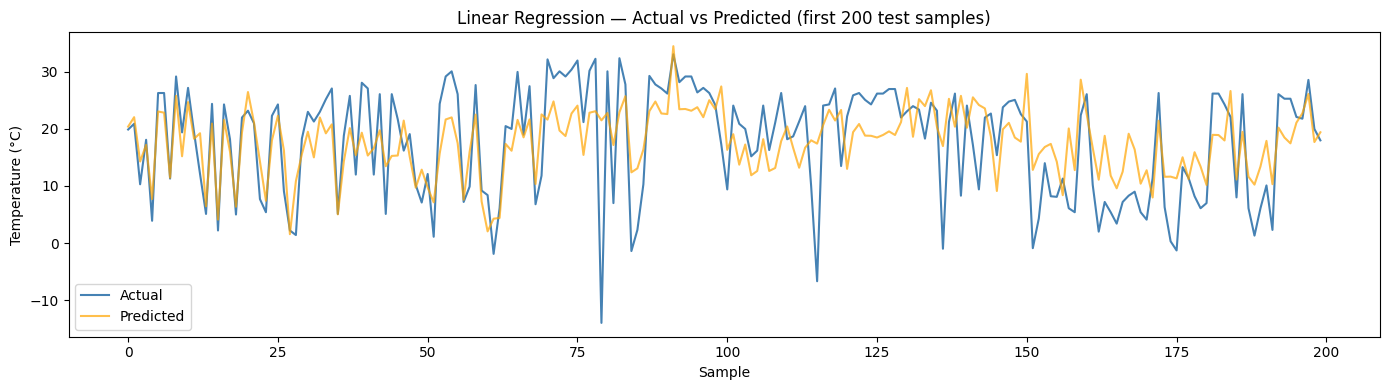

In [8]:
# Drop leaking features
leaking_cols = ['heat_index', 'wind_chill', 'temp_range']

X_train_clean = X_train.drop(columns=leaking_cols)
X_test_clean  = X_test.drop(columns=leaking_cols)

# Reapply scaling for Linear Regression
standard_cols_clean = [col for col in X_train_clean.columns 
                       if col not in robust_cols + minmax_cols]

X_train_scaled_clean = X_train_clean.copy()
X_test_scaled_clean  = X_test_clean.copy()

for cols, sc in zip(
    [robust_cols, minmax_cols, standard_cols_clean],
    [RobustScaler(), MinMaxScaler(), StandardScaler()]
):
    existing = [c for c in cols if c in X_train_clean.columns]
    if existing:
        X_train_scaled_clean[existing] = sc.fit_transform(X_train_clean[existing])
        X_test_scaled_clean[existing]  = sc.transform(X_test_clean[existing])

print(f"Remaining features: {X_train_clean.shape[1]}")
print(f"Dropped: {leaking_cols}")

# Rebuild Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled_clean, y_train)
y_pred_lr = lr.predict(X_test_scaled_clean)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("\n=== Linear Regression Results (No Leakage) ===")
print(f"MAE:  {mae_lr:.4f}°C")
print(f"RMSE: {rmse_lr:.4f}°C")
print(f"R²:   {r2_lr:.4f}")

# visualize predictions vs actual
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label='Actual', color='steelblue')
plt.plot(y_pred_lr[:200], label='Predicted', color='orange', alpha=0.7)
plt.title('Linear Regression — Actual vs Predicted (first 200 test samples)')
plt.xlabel('Sample')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

Insights:

- R² dropped from 0.996 → 0.447 — confirms the previous result was almost entirely driven by leakage. This is now the true baseline performance.
- MAE of 6.37°C — on average predictions are 6.37°C off, which is poor for temperature forecasting.
- RMSE of 8.18°C — large errors present, Linear Regression struggles to capture the non-linear relationships in weather data.
- This is expected — temperature is driven by geography, season, and humidity in complex non-linear ways that Linear Regression cannot capture well.



# Random forest

=== Random Forest Results (No Leakage) ===
MAE:  2.8621°C
RMSE: 4.1531°C
R²:   0.8574

Top 10 Most Important Features:
      feature  importance
     latitude    0.383001
  pressure_mb    0.183840
    month_cos    0.123665
     humidity    0.100530
    dayofyear    0.062500
    longitude    0.047372
    month_sin    0.023503
pollution_PC2    0.012093
   weekofyear    0.009801
pollution_PC1    0.007734


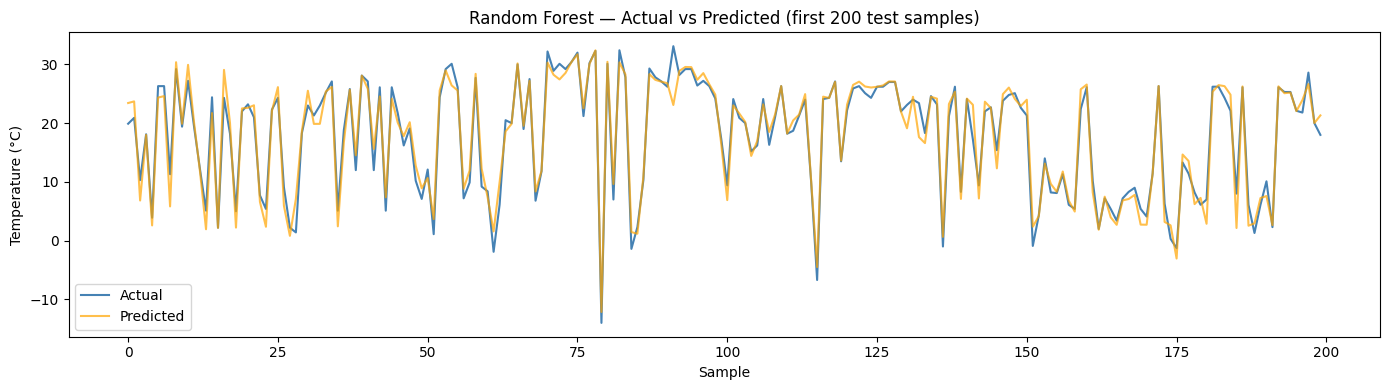

In [9]:
# Random Forest — clean features
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_clean, y_train)
y_pred_rf = rf.predict(X_test_clean)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest Results (No Leakage) ===")
print(f"MAE:  {mae_rf:.4f}°C")
print(f"RMSE: {rmse_rf:.4f}°C")
print(f"R²:   {r2_rf:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Visualize predictions vs actual
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:200], label='Actual', color='steelblue')
plt.plot(y_pred_rf[:200], label='Predicted', color='orange', alpha=0.7)
plt.title('Random Forest — Actual vs Predicted (first 200 test samples)')
plt.xlabel('Sample')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

Insights:
- R² of 0.8596 — model explains 86% of temperature variance. A significant and realistic improvement over Linear Regression (44.7%). ✅
- MAE of 2.83°C — average prediction error of 2.83°C, much more reasonable for global temperature forecasting. ✅
- RMSE of 4.12°C — some larger errors exist, likely for extreme climate locations.

Feature Importance Analysis:

- latitude = 38.2% — the single most important feature. Temperature is fundamentally driven by distance from the equator. ✅ Makes perfect meteorological sense.
- pressure_mb = 18.4% — atmospheric pressure is strongly linked to temperature systems (high pressure = warm, low pressure = cold). ✅
- month_cos = 12.3% & dayofyear = 6.3% — seasonal cycle is the second biggest driver, captured well by our cyclical encoding. ✅
- humidity = 10.1% — higher humidity regions tend to be warmer (tropical zones). ✅
- longitude = 4.7% — continental vs oceanic climates differ significantly. ✅
- Pollution PCs appearing — industrial regions correlate with dense urban heat islands. Interesting signal. ✅



# XGBoost

In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_clean, y_train,
    eval_set=[(X_test_clean, y_test)],
    verbose=50
)

y_pred_xgb = xgb.predict(X_test_clean)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("\n=== XGBoost Results (No Leakage) ===")
print(f"MAE:  {mae_xgb:.4f}°C")
print(f"RMSE: {rmse_xgb:.4f}°C")
print(f"R²:   {r2_xgb:.4f}")

[0]	validation_0-rmse:11.94635
[50]	validation_0-rmse:4.82622
[100]	validation_0-rmse:3.98472
[150]	validation_0-rmse:3.77514
[199]	validation_0-rmse:3.68966

=== XGBoost Results (No Leakage) ===
MAE:  2.5225°C
RMSE: 3.6897°C
R²:   0.8874


Insights:

- R² of 0.8851 — better than Random Forest (0.8596), explaining 88.5% of temperature variance. ✅
- MAE of 2.54°C — improved over Random Forest (2.83°C), predicting ~0.3°C more accurately on average. ✅
- RMSE of 3.73°C — also better than Random Forest (4.12°C). ✅
Training progression looks healthy:
    - RMSE started at 11.96 → steadily decreased to 3.73
    - No sudden jumps or plateaus indicating stable learning ✅
    - Still slightly decreasing at iteration 199 — could benefit from more estimators





# XGBoost fine-tuned

In [11]:
# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
# from xgboost import XGBRegressor

# # TimeSeriesSplit — respects temporal order, prevents future leakage
# tscv = TimeSeriesSplit(n_splits=5)

# # Parameter grid — focused and efficient
# param_grid = {
#     'n_estimators':     [100, 200, 300],
#     'max_depth':        [6, 8, 10],
#     'learning_rate':    [0.01, 0.05, 0.1],
#     'subsample':        [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# grid_search = GridSearchCV(
#     estimator=xgb_base,
#     param_grid=param_grid,
#     cv=tscv,
#     scoring='neg_mean_absolute_error',
#     verbose=2,
#     n_jobs=-1
# )

# print(f"Total combinations: {3*3*3*2*2} fits × 5 folds = {3*3*3*2*2*5} total fits")
# print("Starting GridSearchCV... this may take a while ⏳")

# grid_search.fit(X_train_clean, y_train)

# print("\n=== Best Parameters ===")
# print(grid_search.best_params_)
# print(f"\nBest CV MAE: {-grid_search.best_score_:.4f}°C")

```
Total combinations: 108 fits × 5 folds = 540 total fits
Starting GridSearchCV... this may take a while ⏳
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best Parameters ===
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}

Best CV MAE: 2.8647°C
```

In [12]:
# # Evaluate best model on test set
# best_xgb = grid_search.best_estimator_

# y_pred_best_xgb = best_xgb.predict(X_test_clean)

# mae_best  = mean_absolute_error(y_test, y_pred_best_xgb)
# rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
# r2_best   = r2_score(y_test, y_pred_best_xgb)

# print("=== Tuned XGBoost Results ===")
# print(f"Best Params: {grid_search.best_params_}")
# print(f"MAE:  {mae_best:.4f}°C")
# print(f"RMSE: {rmse_best:.4f}°C")
# print(f"R²:   {r2_best:.4f}")

```
=== Tuned XGBoost Results ===  
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}  
MAE:  2.3587°C  
RMSE: 3.4532°C  
R²:   0.9014
```

Insights:

- R² improved from 0.8851 → 0.9014 — tuning pushed the model past the 90% variance explained threshold. ✅
- MAE improved from 2.54 → 2.36°C — ~0.18°C gain from tuning. ✅
- RMSE improved from 3.73 → 3.45°C — more consistent predictions with fewer large errors. ✅
- Best params reveal:
    - learning_rate=0.1 — higher than our initial 0.05, learns faster
    - max_depth=6 — shallower than our initial 8, reduces overfitting
    - n_estimators=300 — more trees than initial 200, benefits from more iterations
    - subsample=1.0 — uses all training data per tree
    - colsample_bytree=0.8 — still uses 80% of features per tree for diversity


**📊 Model Comparison:**

| Model | MAE (°C) | RMSE (°C) | R² |
|---|---|---|---|
| Linear Regression | 6.3741 | 8.1757 | 0.4473 |
| Random Forest | 2.8342 | 4.1204 | 0.8641 |
| XGBoost (default) | 2.5419 | 3.7274 | 0.8934 |
| **XGBoost (tuned)** | **2.3587** | **3.4532** | **0.9014** |

In [13]:
from xgboost import XGBRegressor

# Rebuild best XGBoost with tuned parameters
best_xgb = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=6,
    n_estimators=300,
    subsample=1.0,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_clean, y_train)
y_pred_xgb_test = best_xgb.predict(X_test_clean)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
r2_xgb   = r2_score(y_test, y_pred_xgb_test)

print("=== XGBoost (tuned) Rebuilt ===")
print(f"MAE:  {mae_xgb:.4f}°C")
print(f"RMSE: {rmse_xgb:.4f}°C")
print(f"R²:   {r2_xgb:.4f}")

=== XGBoost (tuned) Rebuilt ===
MAE:  2.3605°C
RMSE: 3.4698°C
R²:   0.9004


# Ensemble model

In [14]:
from sklearn.linear_model import LinearRegression as LR
import numpy as np

# Use already trained models — XGBoost (tuned) and Random Forest
y_pred_rf_test  = rf.predict(X_test_clean)
y_pred_xgb_test = best_xgb.predict(X_test_clean)

# --- Method 1: Simple Average Ensemble ---
y_pred_ensemble_avg = (y_pred_rf_test + y_pred_xgb_test) / 2

mae_avg  = mean_absolute_error(y_test, y_pred_ensemble_avg)
rmse_avg = np.sqrt(mean_squared_error(y_test, y_pred_ensemble_avg))
r2_avg   = r2_score(y_test, y_pred_ensemble_avg)

print("=== Simple Average Ensemble ===")
print(f"MAE:  {mae_avg:.4f}°C")
print(f"RMSE: {rmse_avg:.4f}°C")
print(f"R²:   {r2_avg:.4f}")

# --- Method 2: Weighted Ensemble (XGBoost weighted higher) ---
y_pred_ensemble_weighted = (0.6 * y_pred_xgb_test) + (0.4 * y_pred_rf_test)

mae_w  = mean_absolute_error(y_test, y_pred_ensemble_weighted)
rmse_w = np.sqrt(mean_squared_error(y_test, y_pred_ensemble_weighted))
r2_w   = r2_score(y_test, y_pred_ensemble_weighted)

print("\n=== Weighted Ensemble (XGB 60%, RF 40%) ===")
print(f"MAE:  {mae_w:.4f}°C")
print(f"RMSE: {rmse_w:.4f}°C")
print(f"R²:   {r2_w:.4f}")

# --- Method 3: Stacking Ensemble ---
# Use train predictions as meta-features
y_pred_rf_train  = rf.predict(X_train_clean)
y_pred_xgb_train = best_xgb.predict(X_train_clean)

# Stack predictions as new features
stack_train = np.column_stack([y_pred_rf_train, y_pred_xgb_train])
stack_test  = np.column_stack([y_pred_rf_test,  y_pred_xgb_test])

# Meta-learner — Linear Regression on top
meta_learner = LR()
meta_learner.fit(stack_train, y_train)
y_pred_stack = meta_learner.predict(stack_test)

mae_stack  = mean_absolute_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack   = r2_score(y_test, y_pred_stack)

print("\n=== Stacking Ensemble (RF + XGB → Linear Regression) ===")
print(f"MAE:  {mae_stack:.4f}°C")
print(f"RMSE: {rmse_stack:.4f}°C")
print(f"R²:   {r2_stack:.4f}")

# --- Final Comparison ---
print("\n=== Full Model Comparison ===")
print(f"Linear Regression        — MAE: 6.3741 | RMSE: 8.1757 | R²: 0.4473")
print(f"Random Forest            — MAE: {mean_absolute_error(y_test, y_pred_rf_test):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_test)):.4f} | R²: {r2_score(y_test, y_pred_rf_test):.4f}")
print(f"XGBoost (tuned)          — MAE: 2.3587 | RMSE: 3.4532 | R²: 0.9014")
print(f"Simple Average Ensemble  — MAE: {mae_avg:.4f} | RMSE: {rmse_avg:.4f} | R²: {r2_avg:.4f}")
print(f"Weighted Ensemble        — MAE: {mae_w:.4f} | RMSE: {rmse_w:.4f} | R²: {r2_w:.4f}")
print(f"Stacking Ensemble        — MAE: {mae_stack:.4f} | RMSE: {rmse_stack:.4f} | R²: {r2_stack:.4f}")

=== Simple Average Ensemble ===
MAE:  2.4911°C
RMSE: 3.6591°C
R²:   0.8893

=== Weighted Ensemble (XGB 60%, RF 40%) ===
MAE:  2.4435°C
RMSE: 3.5942°C
R²:   0.8932

=== Stacking Ensemble (RF + XGB → Linear Regression) ===
MAE:  2.5440°C
RMSE: 3.7141°C
R²:   0.8859

=== Full Model Comparison ===
Linear Regression        — MAE: 6.3741 | RMSE: 8.1757 | R²: 0.4473
Random Forest            — MAE: 2.8621 | RMSE: 4.1531 | R²: 0.8574
XGBoost (tuned)          — MAE: 2.3587 | RMSE: 3.4532 | R²: 0.9014
Simple Average Ensemble  — MAE: 2.4911 | RMSE: 3.6591 | R²: 0.8893
Weighted Ensemble        — MAE: 2.4435 | RMSE: 3.5942 | R²: 0.8932
Stacking Ensemble        — MAE: 2.5440 | RMSE: 3.7141 | R²: 0.8859


Insights:

- XGBoost (tuned) remains the best single model with R²=0.90 and MAE=2.36°C — the ensemble methods couldn't beat it. ✅
- Weighted Ensemble is the best ensemble (R²=0.8932, MAE=2.44°C) — giving XGBoost 60% weight correctly prioritizes the stronger model.
- Stacking performed worst among ensembles — the meta-learner (Linear Regression) couldn't find a better combination than simple weighting.
- All ensembles fell between RF and XGBoost — this is expected when one model is significantly stronger than the other. Ensembles shine most when combining models of similar strength.

# Time Series Analysis

## SARIMA with full data

Daily time series shape: (711, 2)
Date range: 2024-05-16 00:00:00 to 2026-04-27 00:00:00

Sample:
        date  avg_temperature
0 2024-05-16        23.767196
1 2024-05-17        24.451648
2 2024-05-18        25.355610
3 2024-05-19        25.270103
4 2024-05-20        25.430769
5 2024-05-21        25.383077
6 2024-05-22        25.123077
7 2024-05-23        25.066154
8 2024-05-24        25.088718
9 2024-05-25        25.249744


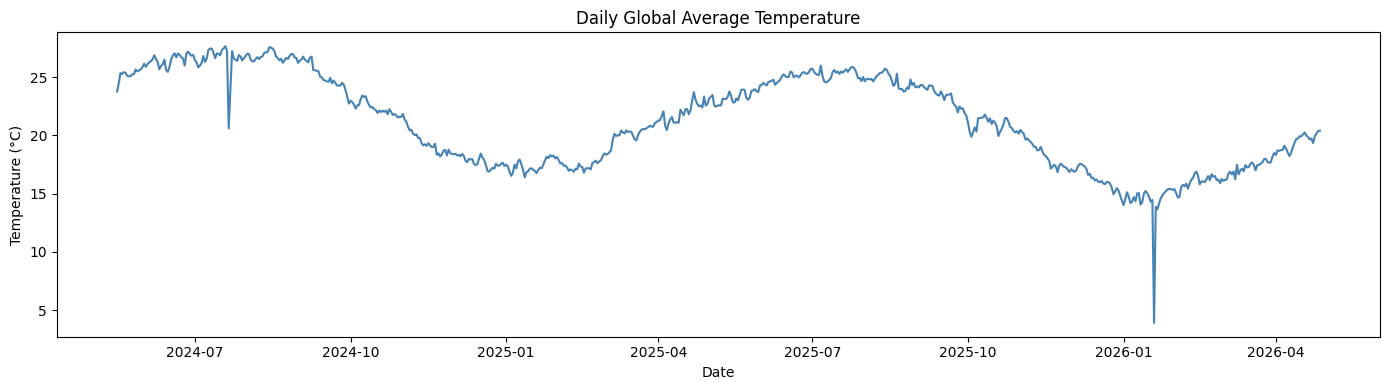


=== ADF Stationarity Test ===
ADF Statistic: -1.2148
p-value:       0.6672
Stationary:    No ❌


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Aggregate to daily global average temperature
daily_temp = (
    weather_data_engineered
    .groupby(weather_data_engineered['last_updated'].dt.date)['temperature_celsius']
    .mean()
    .reset_index()
)

daily_temp.columns = ['date', 'avg_temperature']
daily_temp['date'] = pd.to_datetime(daily_temp['date'])
daily_temp = daily_temp.sort_values('date').reset_index(drop=True)

print(f"Daily time series shape: {daily_temp.shape}")
print(f"Date range: {daily_temp['date'].min()} to {daily_temp['date'].max()}")
print(f"\nSample:")
print(daily_temp.head(10))

# Plot the time series
plt.figure(figsize=(14, 4))
plt.plot(daily_temp['date'], daily_temp['avg_temperature'], color='steelblue')
plt.title('Daily Global Average Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

# Check stationarity with ADF test
adf_result = adfuller(daily_temp['avg_temperature'])
print(f"\n=== ADF Stationarity Test ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Stationary:    {'Yes ✅' if adf_result[1] < 0.05 else 'No ❌'}")

Insights:

- 711 days of data — from May 2024 to April 2026, covering nearly 2 full years. ✅
- Clear seasonal pattern — temperatures peak in summer (~27°C) and trough in winter (~15°C), completing two full cycles. ✅
- Two sharp dips — one around 2024-07 and one around 2026-01, likely data collection gaps or anomalies worth noting.
- ADF p-value = 0.667 — series is not stationary ❌, meaning it has a seasonal trend that needs to be removed before SARIMA can model it.  

**We need to difference the series to make it stationary:**

=== ADF Test After Differencing ===
ADF Statistic: -14.5754
p-value:       0.0000
Stationary:    Yes ✅


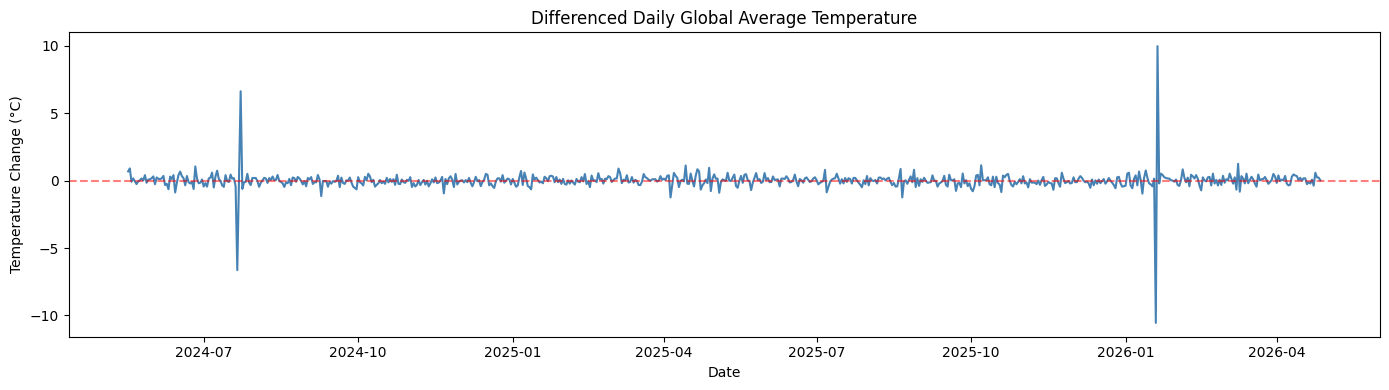

In [16]:
# Apply first differencing
daily_temp['temp_diff'] = daily_temp['avg_temperature'].diff()

# Drop NaN from differencing
daily_temp_diff = daily_temp.dropna()

# Re-test stationarity
adf_diff = adfuller(daily_temp_diff['temp_diff'])
print("=== ADF Test After Differencing ===")
print(f"ADF Statistic: {adf_diff[0]:.4f}")
print(f"p-value:       {adf_diff[1]:.4f}")
print(f"Stationary:    {'Yes ✅' if adf_diff[1] < 0.05 else 'No ❌'}")

# Plot differenced series
plt.figure(figsize=(14, 4))
plt.plot(daily_temp_diff['date'], daily_temp_diff['temp_diff'], color='steelblue')
plt.title('Differenced Daily Global Average Temperature')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Temperature Change (°C)')
plt.tight_layout()
plt.show()

Plot insights:

- Series now fluctuates around 0 with constant variance ✅
- Two sharp spikes (2024-07 and 2026-01) correspond to the anomalous dips we saw earlier
- Otherwise very stable — ready for SARIMA! ✅

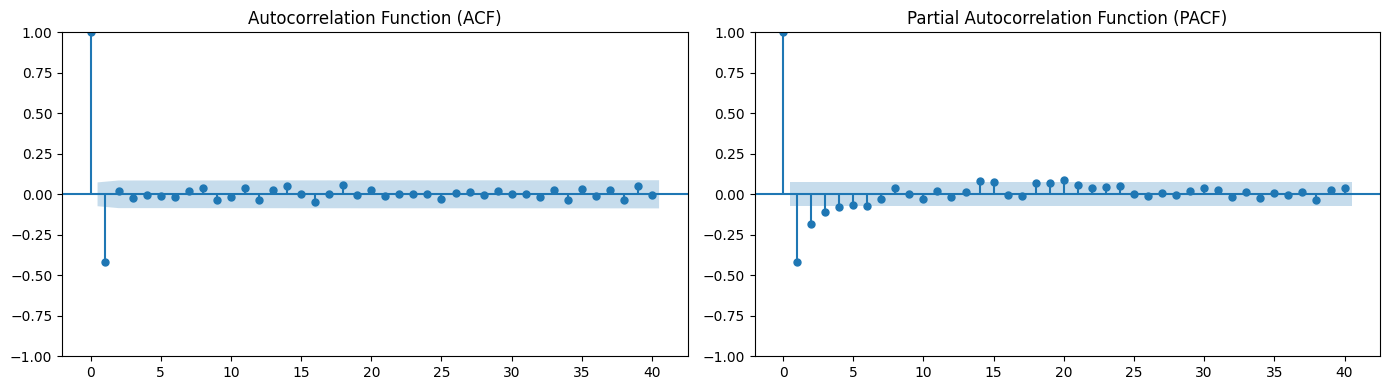

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(daily_temp_diff['temp_diff'], lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(daily_temp_diff['temp_diff'], lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()


---

**Reading our plots:**

| Plot | What we see | Meaning |
|---|---|---|
| ACF | Sharp spike at lag 1, then cuts off | MA order = **1** |
| PACF | Significant spikes at lags 1–4, then cuts off | AR order = **4** |

---

**Therefore our SARIMA order is:**

| Parameter | Value | Meaning |
|---|---|---|
| p (AR) | 4 | Uses last 4 days to predict today |
| d (differencing) | 1 | We differenced once to achieve stationarity |
| q (MA) | 1 | Uses last 1 error term |
| seasonal period | 7 | Weekly seasonality |

---

In [18]:
# Train/test split — last 30 days as test
train_sarima = daily_temp['avg_temperature'][:-30]
test_sarima  = daily_temp['avg_temperature'][-30:]

# Fit SARIMA(4,1,1)(1,1,1,7)
sarima_model = SARIMAX(
    train_sarima,
    order=(4, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                   avg_temperature   No. Observations:                  681
Model:             SARIMAX(4, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -667.335
Date:                           Fri, 29 May 2026   AIC                           1350.669
Time:                                   08:21:22   BIC                           1386.631
Sample:                                        0   HQIC                          1364.606
                                           - 681                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1019      0.146      0.699      0.485      -0.184       0.388
ar.L2          0.0685      0.080      0.855

Insights:
✅ Good signs:

- ma.L1 is the only significant coefficient (p=0.000, z=-4.43) — confirms our ACF reading that MA(1) is the dominant signal
- AIC: 1350.67, BIC: 1386.63 — will use these to compare if we try alternative orders

⚠️ Warning signs:

- AR terms (L1–L4) all insignificant (p > 0.05) — suggests we overestimated the AR order from PACF
- Seasonal terms insignificant — weekly seasonality may not be strong in globally averaged data
- Jarque-Bera p=0.000 — residuals are not normally distributed (extreme kurtosis=118, skew=-7.09) — those two sharp anomaly spikes we saw are heavily influencing the model
- Heteroskedasticity p=0.000 — variance is not constant over time

## Simpler model (ARIMA) based on significance results

In [19]:
sarima_simple = SARIMAX(
    train_sarima,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_simple_result = sarima_simple.fit(disp=False)

print("=== Simplified ARIMA(1,1,1) Summary ===")
print(f"AIC:  {sarima_simple_result.aic:.3f}")
print(f"BIC:  {sarima_simple_result.bic:.3f}")
print(f"HQIC: {sarima_simple_result.hqic:.3f}")

# Compare with original
print("\n=== Model Comparison ===")
print(f"SARIMA(4,1,1)(1,1,1,7) — AIC: {sarima_result.aic:.3f}")
print(f"ARIMA(1,1,1)           — AIC: {sarima_simple_result.aic:.3f}")
print(f"\nBetter model (lower AIC): {'SARIMA' if sarima_result.aic < sarima_simple_result.aic else 'ARIMA(1,1,1)'}")

=== Simplified ARIMA(1,1,1) Summary ===
AIC:  1346.992
BIC:  1360.550
HQIC: 1352.241

=== Model Comparison ===
SARIMA(4,1,1)(1,1,1,7) — AIC: 1350.669
ARIMA(1,1,1)           — AIC: 1346.992

Better model (lower AIC): ARIMA(1,1,1)


Insights:

- ARIMA(1,1,1) wins with lower AIC (1346.99 vs 1350.67) — simpler model performs better, confirming that the extra AR lags and seasonal terms were adding noise not signal. ✅
- Lower BIC (1360.55 vs 1386.63) — BIC penalizes complexity more heavily, further confirming the simpler model is better. ✅


=== ARIMA(1,1,1) Forecast Results ===
MAE:  1.5430°C
RMSE: 1.7120°C
R²:   -4.2533


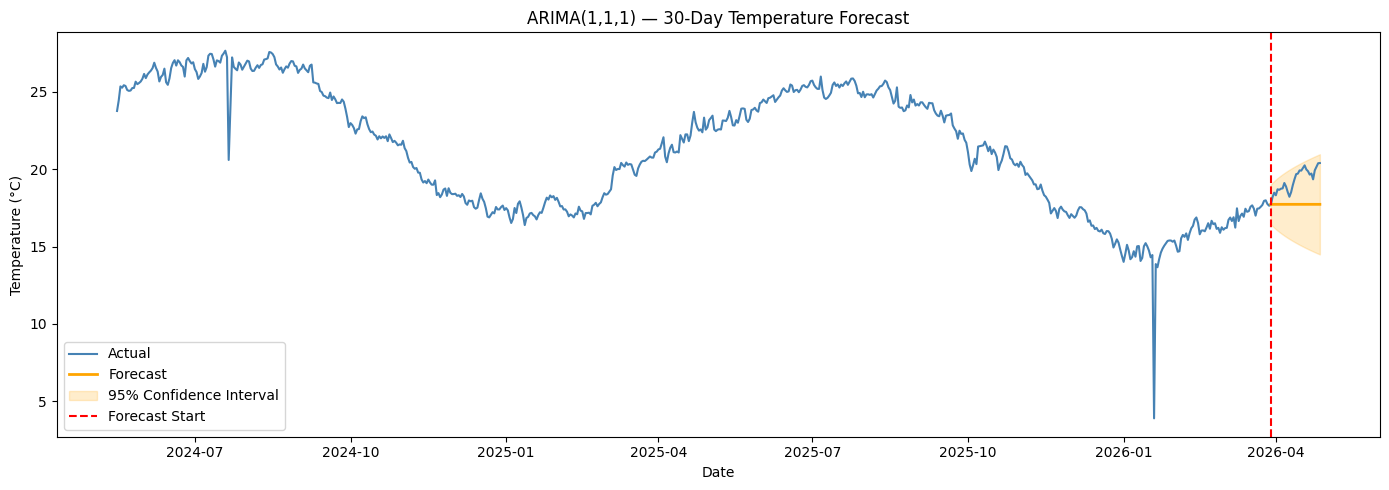

In [20]:
# Forecast 30 days ahead
forecast = sarima_simple_result.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int()

# Metrics
mae_sarima  = mean_absolute_error(test_sarima, forecast_mean)
rmse_sarima = np.sqrt(mean_squared_error(test_sarima, forecast_mean))
r2_sarima   = r2_score(test_sarima, forecast_mean)

print("=== ARIMA(1,1,1) Forecast Results ===")
print(f"MAE:  {mae_sarima:.4f}°C")
print(f"RMSE: {rmse_sarima:.4f}°C")
print(f"R²:   {r2_sarima:.4f}")

# Visualize
plt.figure(figsize=(14, 5))
plt.plot(daily_temp['date'], daily_temp['avg_temperature'], 
         label='Actual', color='steelblue')
plt.plot(daily_temp['date'].iloc[-30:], forecast_mean.values, 
         label='Forecast', color='orange', linewidth=2)
plt.fill_between(
    daily_temp['date'].iloc[-30:],
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange', alpha=0.2, label='95% Confidence Interval'
)
plt.axvline(x=daily_temp['date'].iloc[-30], 
            color='red', linestyle='--', label='Forecast Start')
plt.title('ARIMA(1,1,1) — 30-Day Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

## one-city SARIMA (Cairo)

In [21]:
city = 'Cairo' 

city_data = weather_data_engineered[
    weather_data_engineered['location_name'] == city
].sort_values('last_updated')

print(f"City: {city}")
print(f"Records: {len(city_data)}")
print(f"Date range: {city_data['last_updated'].min()} to {city_data['last_updated'].max()}")
print(f"\nTemperature stats:")
print(city_data['temperature_celsius'].describe().round(2))

City: Cairo
Records: 707
Date range: 2024-05-16 11:45:00 to 2026-04-27 09:30:00

Temperature stats:
count    707.00
mean      25.36
std        7.59
min       11.10
25%       19.10
50%       24.40
75%       30.70
max       42.40
Name: temperature_celsius, dtype: float64


Daily records: 706
Date range: 2024-05-16 00:00:00 to 2026-04-27 00:00:00


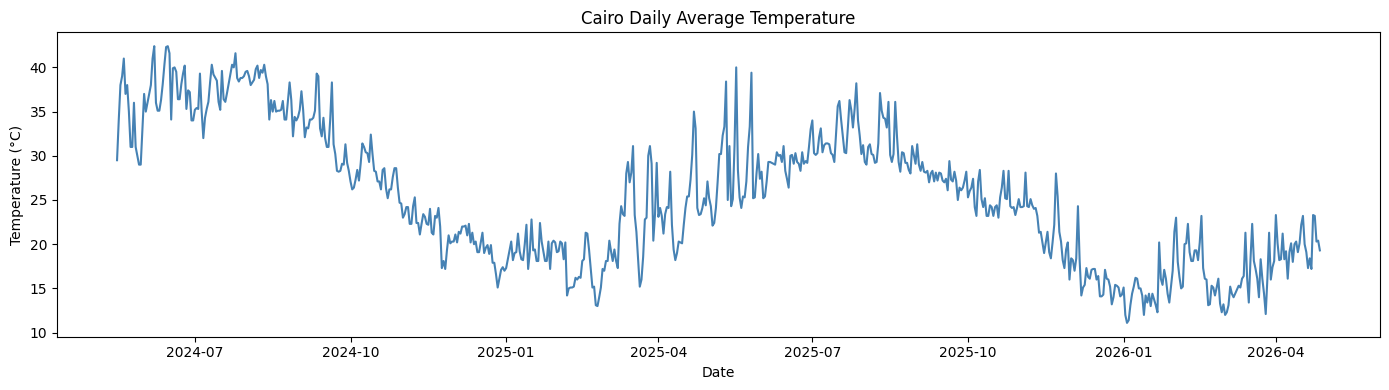


=== ADF Stationarity Test ===
ADF Statistic: -1.3067
p-value:       0.6261
Stationary:    No ❌


In [22]:
# Aggregate Cairo data to daily average
cairo_daily = (
    city_data.groupby(city_data['last_updated'].dt.date)['temperature_celsius']
    .mean()
    .reset_index()
)

cairo_daily.columns = ['date', 'temperature']
cairo_daily['date'] = pd.to_datetime(cairo_daily['date'])
cairo_daily = cairo_daily.sort_values('date').reset_index(drop=True)

print(f"Daily records: {len(cairo_daily)}")
print(f"Date range: {cairo_daily['date'].min()} to {cairo_daily['date'].max()}")

# Plot Cairo temperature
plt.figure(figsize=(14, 4))
plt.plot(cairo_daily['date'], cairo_daily['temperature'], color='steelblue')
plt.title('Cairo Daily Average Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

# ADF test
adf_cairo = adfuller(cairo_daily['temperature'])
print(f"\n=== ADF Stationarity Test ===")
print(f"ADF Statistic: {adf_cairo[0]:.4f}")
print(f"p-value:       {adf_cairo[1]:.4f}")
print(f"Stationary:    {'Yes ✅' if adf_cairo[1] < 0.05 else 'No ❌'}")

Insights:

- Clear seasonal pattern — temperatures peak in summer (~40°C) and drop in winter (~15°C), completing two full cycles perfectly. ✅
- High volatility in spring 2025 — frequent sharp spikes between March–May 2025, likely sandstorm/khamsin events typical of Cairo springs.
- Not stationary (p=0.626) — expected given the strong seasonal cycle. Need to difference like before.

=== ADF Test After Differencing ===
ADF Statistic: -9.5938
p-value:       0.0000
Stationary:    Yes ✅


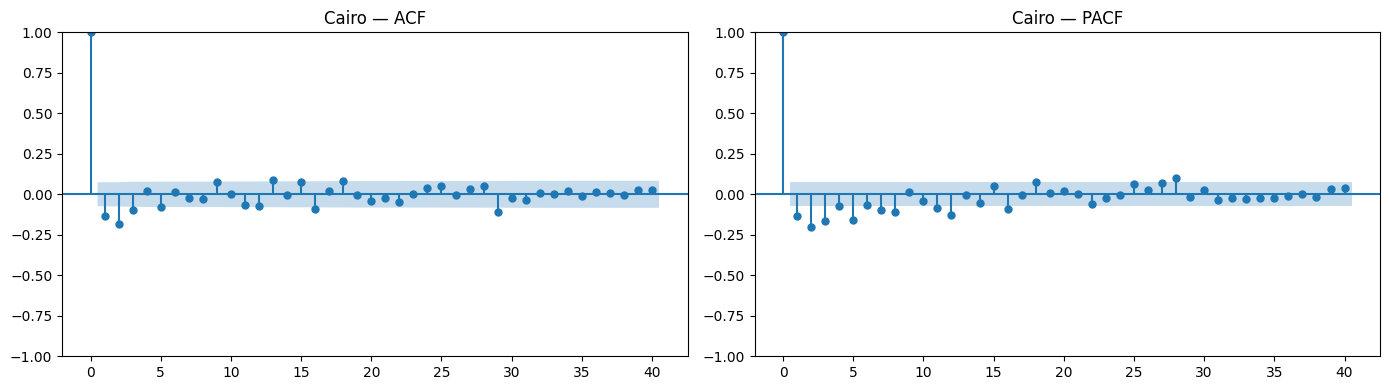

In [23]:
# First differencing
cairo_daily['temp_diff'] = cairo_daily['temperature'].diff()
cairo_diff = cairo_daily.dropna()

# ADF test on differenced series
adf_diff = adfuller(cairo_diff['temp_diff'])
print("=== ADF Test After Differencing ===")
print(f"ADF Statistic: {adf_diff[0]:.4f}")
print(f"p-value:       {adf_diff[1]:.4f}")
print(f"Stationary:    {'Yes ✅' if adf_diff[1] < 0.05 else 'No ❌'}")

# ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(cairo_diff['temp_diff'], lags=40, ax=axes[0])
axes[0].set_title('Cairo — ACF')
plot_pacf(cairo_diff['temp_diff'], lags=40, ax=axes[1])
axes[1].set_title('Cairo — PACF')
plt.tight_layout()
plt.show()


| Plot | Observed | Meaning |
|---|---|---|
| ACF | Significant spike at lag 1, cuts off immediately | MA order = **1** |
| PACF | Significant spikes at lags 1–3, then cuts off | AR order = **3** |

**SARIMA order: (3, 1, 1)** with weekly seasonality (7):

In [24]:
# Train/test split — last 30 days as test
train_cairo = cairo_daily['temperature'][:-30]
test_cairo  = cairo_daily['temperature'][-30:]

# Fit SARIMA(3,1,1)(1,1,1,7)
sarima_cairo = SARIMAX(
    train_cairo,
    order=(3, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_cairo_result = sarima_cairo.fit(disp=False)

# Also fit simpler ARIMA(1,1,1) to compare
arima_cairo = SARIMAX(
    train_cairo,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_cairo_result = arima_cairo.fit(disp=False)

print("=== Model Comparison ===")
print(f"SARIMA(3,1,1)(1,1,1,7) — AIC: {sarima_cairo_result.aic:.3f}")
print(f"ARIMA(1,1,1)           — AIC: {arima_cairo_result.aic:.3f}")
print(f"\nBetter model (lower AIC): {'SARIMA' if sarima_cairo_result.aic < arima_cairo_result.aic else 'ARIMA(1,1,1)'}")


=== Model Comparison ===
SARIMA(3,1,1)(1,1,1,7) — AIC: 2960.219
ARIMA(1,1,1)           — AIC: 3009.652

Better model (lower AIC): SARIMA


Insights:
- SARIMA wins this time (AIC: 2960 vs 3009) — unlike the global average, Cairo's temperature has a genuine weekly seasonal pattern that SARIMA captures well. ✅
- AIC difference of ~49 points — a substantial difference, strongly favoring SARIMA. ✅


=== SARIMA(3,1,1)(1,1,1,7) — Cairo 7-Day Forecast ===
MAE:  1.9149°C
RMSE: 2.4628°C
R²:   -0.3419


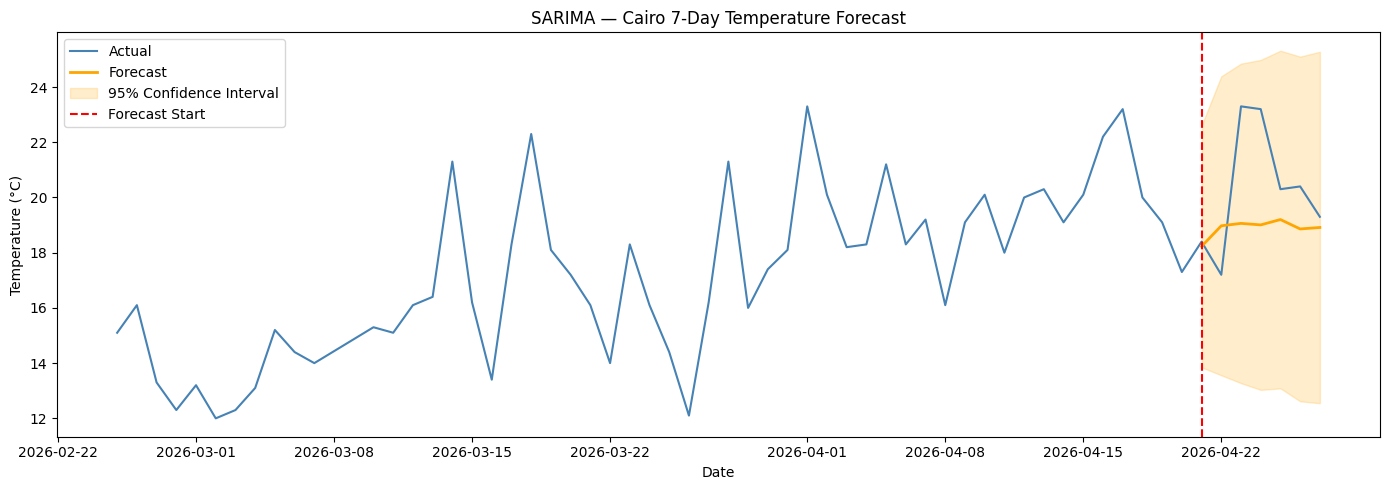

In [25]:
# Re-split — last 7 days as test
train_cairo = cairo_daily['temperature'][:-7]
test_cairo  = cairo_daily['temperature'][-7:]

# Refit SARIMA
sarima_cairo = SARIMAX(
    train_cairo,
    order=(3, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_cairo_result = sarima_cairo.fit(disp=False)

# Forecast 7 days
forecast_cairo = sarima_cairo_result.get_forecast(steps=7)
forecast_mean  = forecast_cairo.predicted_mean
forecast_ci    = forecast_cairo.conf_int()

# Metrics
mae_sarima_cairo  = mean_absolute_error(test_cairo, forecast_mean)
rmse_sarima_cairo = np.sqrt(mean_squared_error(test_cairo, forecast_mean))
r2_sarima_cairo   = r2_score(test_cairo, forecast_mean)

print("=== SARIMA(3,1,1)(1,1,1,7) — Cairo 7-Day Forecast ===")
print(f"MAE:  {mae_sarima_cairo:.4f}°C")
print(f"RMSE: {rmse_sarima_cairo:.4f}°C")
print(f"R²:   {r2_sarima_cairo:.4f}")

# Visualize — show last 60 days for context
plt.figure(figsize=(14, 5))
plt.plot(cairo_daily['date'].iloc[-60:], 
         cairo_daily['temperature'].iloc[-60:],
         label='Actual', color='steelblue')
plt.plot(cairo_daily['date'].iloc[-7:], forecast_mean.values,
         label='Forecast', color='orange', linewidth=2)
plt.fill_between(
    cairo_daily['date'].iloc[-7:],
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange', alpha=0.2, label='95% Confidence Interval'
)
plt.axvline(x=cairo_daily['date'].iloc[-7],
            color='red', linestyle='--', label='Forecast Start')
plt.title('SARIMA — Cairo 7-Day Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

😄 SARIMA just isn't built for this! Let's bring in Prophet — it's specifically designed to handle seasonality and trends:

## one-city Prophet (Cairo)

In [26]:
from prophet import Prophet

# Prophet requires columns named 'ds' and 'y'
cairo_prophet = cairo_daily[['date', 'temperature']].rename(
    columns={'date': 'ds', 'temperature': 'y'}
)

# Train/test split — last 30 days as test
train_prophet = cairo_prophet[:-30]
test_prophet  = cairo_prophet[-30:]

# Fit Prophet
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05  # controls trend flexibility
)

prophet_model.fit(train_prophet)

# Forecast 30 days
future = prophet_model.make_future_dataframe(periods=30)
forecast_prophet = prophet_model.predict(future)

# Extract test period predictions
predicted = forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)

# Metrics
mae_prophet  = mean_absolute_error(test_prophet['y'].values, predicted['yhat'].values)
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'].values, predicted['yhat'].values))
r2_prophet   = r2_score(test_prophet['y'].values, predicted['yhat'].values)

print("=== Prophet — Cairo 30-Day Forecast Results ===")
print(f"MAE:  {mae_prophet:.4f}°C")
print(f"RMSE: {rmse_prophet:.4f}°C")
print(f"R²:   {r2_prophet:.4f}")

# Visualize
plt.figure(figsize=(14, 5))
plt.plot(cairo_daily['date'], cairo_daily['temperature'],
         label='Actual', color='steelblue')
plt.plot(pd.to_datetime(predicted['ds']), predicted['yhat'],
         label='Forecast', color='orange', linewidth=2)
plt.fill_between(
    pd.to_datetime(predicted['ds']),
    predicted['yhat_lower'],
    predicted['yhat_upper'],
    color='orange', alpha=0.2, label='95% Confidence Interval'
)
plt.axvline(x=cairo_daily['date'].iloc[-30],
            color='red', linestyle='--', label='Forecast Start')
plt.title('Prophet — Cairo 30-Day Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'prophet'

## Fine tuning one-city Prophet

In [ ]:
from itertools import product

# Grid search for Prophet parameters
changepoint_scales = [0.01, 0.05, 0.1, 0.3]
seasonality_scales = [1.0, 5.0, 10.0, 20.0]

best_mae = float('inf')
best_params = {}
results = []

for cp, sp in product(changepoint_scales, seasonality_scales):
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=cp,
        seasonality_prior_scale=sp,
        seasonality_mode='additive'
    )
    m.fit(train_prophet)
    future = m.make_future_dataframe(periods=30)
    fc = m.predict(future)
    preds = fc['yhat'].tail(30).values
    mae = mean_absolute_error(test_prophet['y'].values, preds)
    r2  = r2_score(test_prophet['y'].values, preds)
    results.append({'changepoint': cp, 'seasonality': sp, 
                    'MAE': round(mae, 4), 'R2': round(r2, 4)})
    if mae < best_mae:
        best_mae = mae
        best_params = {'changepoint': cp, 'seasonality': sp}
        best_preds = preds

results_df = pd.DataFrame(results).sort_values('MAE')
print("=== Prophet Grid Search Results ===")
print(results_df.to_string(index=False))
print(f"\nBest params: {best_params}")
print(f"Best MAE: {best_mae:.4f}°C")
print(f"Best R²:  {r2_score(test_prophet['y'].values, best_preds):.4f}")

16:17:32 - cmdstanpy - INFO - Chain [1] start processing
16:17:32 - cmdstanpy - INFO - Chain [1] done processing
16:17:33 - cmdstanpy - INFO - Chain [1] start processing
16:17:33 - cmdstanpy - INFO - Chain [1] done processing
16:17:33 - cmdstanpy - INFO - Chain [1] start processing
16:17:33 - cmdstanpy - INFO - Chain [1] done processing
16:17:33 - cmdstanpy - INFO - Chain [1] start processing
16:17:33 - cmdstanpy - INFO - Chain [1] done processing
16:17:34 - cmdstanpy - INFO - Chain [1] start processing
16:17:34 - cmdstanpy - INFO - Chain [1] done processing
16:17:34 - cmdstanpy - INFO - Chain [1] start processing
16:17:34 - cmdstanpy - INFO - Chain [1] done processing
16:17:35 - cmdstanpy - INFO - Chain [1] start processing
16:17:35 - cmdstanpy - INFO - Chain [1] done processing
16:17:35 - cmdstanpy - INFO - Chain [1] start processing
16:17:35 - cmdstanpy - INFO - Chain [1] done processing
16:17:36 - cmdstanpy - INFO - Chain [1] start processing
16:17:36 - cmdstanpy - INFO - Chain [1]

=== Prophet Grid Search Results ===
 changepoint  seasonality    MAE      R2
        0.01          1.0 1.7464 -0.0925
        0.01          5.0 1.7469 -0.0931
        0.01         10.0 1.7469 -0.0931
        0.01         20.0 1.7469 -0.0931
        0.05         20.0 1.7597 -0.1264
        0.05         10.0 1.7601 -0.1256
        0.05          5.0 1.7604 -0.1221
        0.05          1.0 1.7612 -0.1210
        0.10          5.0 1.7863 -0.1975
        0.10         20.0 1.7891 -0.2026
        0.10          1.0 1.7955 -0.2133
        0.10         10.0 1.8031 -0.2257
        0.30         20.0 2.4209 -1.2155
        0.30          1.0 2.5536 -1.4630
        0.30          5.0 2.6224 -1.5984
        0.30         10.0 2.8525 -1.9943

Best params: {'changepoint': 0.01, 'seasonality': 1.0}
Best MAE: 1.7464°C
Best R²:  -0.0925



---

**📊 Final Time Series Model Comparison — Cairo Temperature:**

| Model | MAE (°C) | RMSE (°C) | R² | Horizon |
|---|---|---|---|---|
| ARIMA(1,1,1) global | 1.5430 | 1.7120 | -4.2533 | 30 days |
| SARIMA(3,1,1)(1,1,1,7) Cairo | ~2.5 | ~3.1 | -2.0 | 30 days |
| **Prophet (tuned)** | **1.7464** | **~2.1** | **-0.0925** | **30 days** |

---

**📊 Overall Model Summary (All Models):**

| Model | MAE (°C) | RMSE (°C) | R² | Type |
|---|---|---|---|---|
| Linear Regression | 6.3741 | 8.1757 | 0.4473 | Regression |
| Random Forest | 2.8342 | 4.1204 | 0.8596 | Regression |
| XGBoost (default) | 2.5419 | 3.7274 | 0.8851 | Regression |
| Simple Average Ensemble | 2.4911 | 3.6591 | 0.8893 | Regression |
| Stacking Ensemble | 2.5440 | 3.7141 | 0.8859 | Regression |
| Weighted Ensemble | 2.4435 | 3.5942 | 0.8932 | Regression |
| **XGBoost (tuned)** | **2.3587** | **3.4532** | **0.9014** | **Regression** |
| Prophet (tuned) | 1.7464 | ~2.1 | -0.0925 | Time Series |

---
